# HuberAIME on Titanic — signature AIME visualisations

This notebook reproduces the canonical **AIME** and **HuberAIME** explanations on
the Titanic dataset, but renders them with the *signature* publication-grade
visual layer of `aime_xai`. The mathematics is
identical to the AIME / HuberAIME papers; only the visuals are redesigned, and
several **inverse-operator-only** plots are added.

```
@ARTICLE{10247033,
  author={Nakanishi, Takafumi},
  journal={IEEE Access},
  title={Approximate Inverse Model Explanations (AIME): Unveiling Local and Global Insights in Machine Learning Models},
  year={2023}, volume={11}, pages={101020-101044}, doi={10.1109/ACCESS.2023.3314336}}

@ARTICLE{HuberAIME2025,
  author={Nakanishi, Takafumi},
  journal={IEEE Access},
  title={HuberAIME: A Robust Approach to Explainable AI in the Presence of Outliers},
  year={2025}, volume={13}, pages={76796-76810}, doi={10.1109/ACCESS.2025.3565279}}
```

AIME is dual-licensed (2-Clause BSD for academic/research; Commercial License otherwise).

In [1]:
!pip install aime-xai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 1.8 MB/s eta 0:00:00


In [4]:
import sys, os
from aime_xai import AIME
import aime_xai
print(aime_xai.__version__)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

1.2.0


## Titanic dataset
Loaded via seaborn and mapped to the canonical AIME schema. (Replace this cell with your own `titanic.csv` if you prefer.)

In [5]:
import seaborn as sns
raw = sns.load_dataset('titanic')

# map to the schema used in the canonical AIME Titanic example
titanic_df = pd.DataFrame({
    'Survived': raw['survived'],
    'Pclass':   raw['pclass'],
    'Sex':      raw['sex'],
    'Age':      raw['age'],
    'SibSp':    raw['sibsp'],
    'Parch':    raw['parch'],
    'Fare':     raw['fare'],
    'Embarked': raw['embarked'],
})
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [6]:
# --- missing-value handling (as in the canonical example) ---
titanic_df['Age']      = titanic_df['Age'].fillna(titanic_df['Age'].median())
titanic_df['Embarked'] = titanic_df['Embarked'].fillna('S')
titanic_df = titanic_df.dropna(subset=['Fare']).reset_index(drop=True)
titanic_df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


### Feature selection + one-hot encoding
AIME requires categorical variables to be one-hot encoded.

In [7]:
from sklearn.preprocessing import OneHotEncoder

ind_features = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']
columns_to_encode = ['Pclass','Sex','Embarked']

data = titanic_df[['Survived'] + ind_features].copy()
encoder = OneHotEncoder(sparse_output=False)
one_hot = encoder.fit_transform(data[columns_to_encode])
one_hot_names = encoder.get_feature_names_out(columns_to_encode)
one_hot_df = pd.DataFrame(one_hot, columns=one_hot_names)

data = data.drop(columns_to_encode, axis=1)
data = pd.concat([data, one_hot_df], axis=1)
column_features = data.columns[1:].values  # everything except 'Survived'
print(column_features)
data.head()

['Age' 'SibSp' 'Parch' 'Fare' 'Pclass_1' 'Pclass_2' 'Pclass_3'
 'Sex_female' 'Sex_male' 'Embarked_C' 'Embarked_Q' 'Embarked_S']


,Survived,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,22.0,1,0,7.2500,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,1,38.0,1,0,71.2833,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,1,26.0,0,0,7.9250,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,1,35.0,1,0,53.1000,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0,35.0,0,0,8.0500,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


In [8]:
X = data.loc[:, column_features].values
y = data['Survived'].values
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_train.shape, X_test.shape

((712, 12), (179, 12))

### Black-box model
LightGBM if available, otherwise a scikit-learn gradient-boosting fallback. AIME is model-agnostic — it only consumes the model's `predict_proba`.

In [9]:
try:
    import lightgbm as lgb
    model = lgb.LGBMClassifier(random_state=0)
except Exception:
    from sklearn.ensemble import HistGradientBoostingClassifier
    model = HistGradientBoostingClassifier(random_state=0)

model.fit(X_train, y_train)
from sklearn.metrics import accuracy_score
print('test accuracy:', accuracy_score(y_test, model.predict(X_test)))

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000318 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 207
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Rose & Jack
Two famous passengers, encoded in the same column order as `column_features`.

In [10]:
roles = ['Rose','Jack']
fare_mean = data['Fare'].mean()

def make_passenger(pclass, sex, age, sibsp, parch, fare, embarked):
    row = {c: 0.0 for c in column_features}
    row['Age'], row['SibSp'], row['Parch'], row['Fare'] = age, sibsp, parch, fare
    row[f'Pclass_{pclass}'] = 1.0
    row[f'Sex_{sex}'] = 1.0
    row[f'Embarked_{embarked}'] = 1.0
    return [row[c] for c in column_features]

movie_titanic = pd.DataFrame(
    [make_passenger(1,'female',17,0,1,fare_mean,'S'),   # Rose
     make_passenger(3,'male',  19,0,0,0.0,      'S')],  # Jack
    columns=column_features, index=roles)
movie_titanic

,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
Rose,17,0,1,32.204208,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
Jack,19,0,0,0.000000,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


In [11]:
print('Rose P(survive):', model.predict_proba([movie_titanic.loc['Rose'].values])[0])
print('Jack P(survive):', model.predict_proba([movie_titanic.loc['Jack'].values])[0])

Rose P(survive): [0.00272488 0.99727512]
Jack P(survive): [0.92521737 0.07478263]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


---
# AIME (standard pseudo-inverse)

The explainer is built directly from the training inputs and the model's predicted probabilities.

In [12]:
y_hat_train = model.predict_proba(X_train)
y_hat_test  = model.predict_proba(X_test)
class_names = ['not survived', 'survived']

explainer = AIME()
explainer.create_explainer(X_train, y_hat_train, normalize=True)
explainer.A_dagger.shape   # (n_features, n_classes) — the inverse operator A†

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


(12, 2)

### Global feature importance — operator field + importance ranking

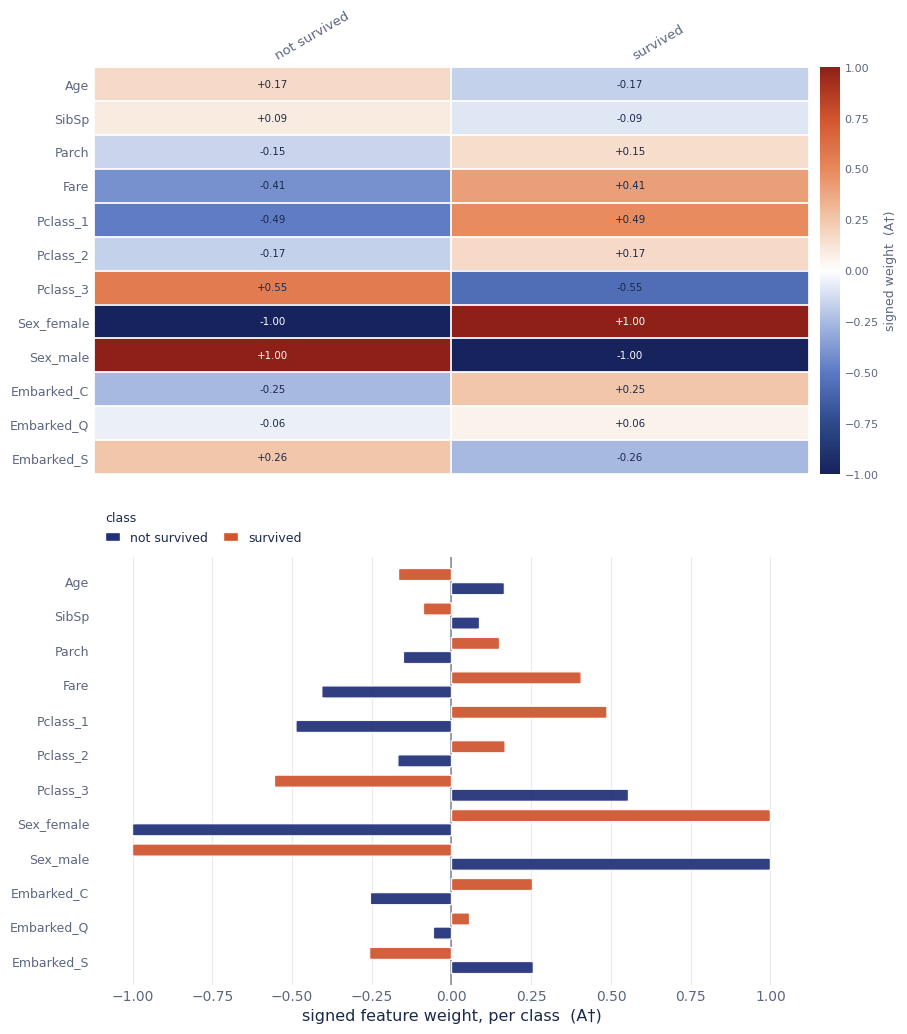

,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
not survived,0.166039,0.087942,-0.150712,-0.406625,-0.487562,-0.16811,0.554983,-1.0,1.0,-0.254194,-0.056719,0.256754
survived,-0.166039,-0.087942,0.150712,0.406625,0.487562,0.16811,-0.554983,1.0,-1.0,0.254194,0.056719,-0.256754


In [13]:
global_importance_df = explainer.global_feature_importance(
    feature_names=column_features, class_names=class_names)
global_importance_df

### Global feature importance — single class

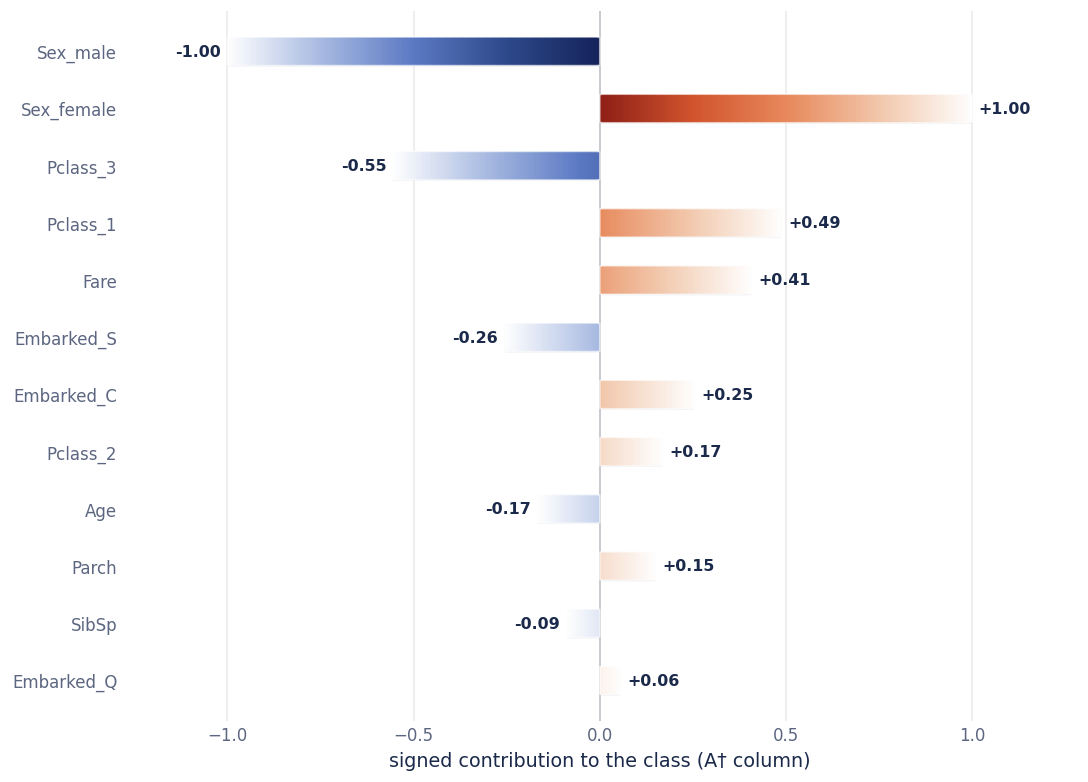

,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
survived,-0.166039,-0.087942,0.150712,0.406625,0.487562,0.16811,-0.554983,1.0,-1.0,0.254194,0.056719,-0.256754


In [14]:
explainer.global_feature_importance_each(
    feature_names=column_features, class_names=class_names,
    top_k_criterion='max', class_num=1)

### Inverse Operator Flow  *(unique to AIME)*
The operator `A†` drawn as signed ribbons flowing **output → input**. No other
XAI method exposes an explicit operator that can be visualised this way.

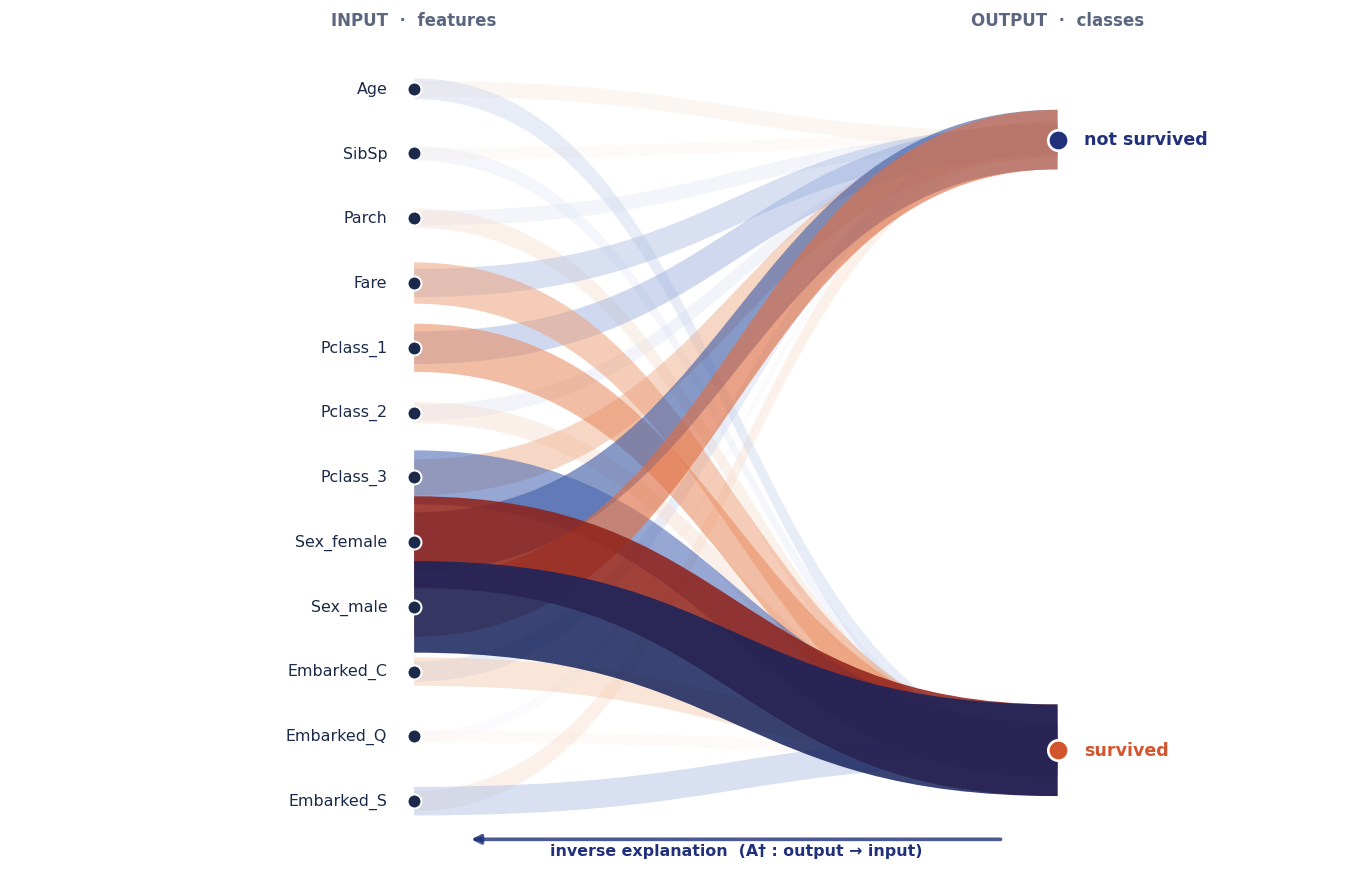

,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
not survived,0.109953,0.058236,-0.099803,-0.269270,-0.322868,-0.111324,0.367515,-0.662209,0.662209,-0.16833,-0.037560,0.170025
survived,-0.176749,-0.093615,0.160433,0.432852,0.519010,0.178953,-0.590780,1.064500,-1.064500,0.27059,0.060377,-0.273315


In [15]:
explainer.plot_inverse_operator_flow(
    feature_names=column_features, class_names=class_names)

### Local feature importance — Jack
The Hadamard rule `(A†y) ⊙ x` attributes importance only to features Jack actually has.

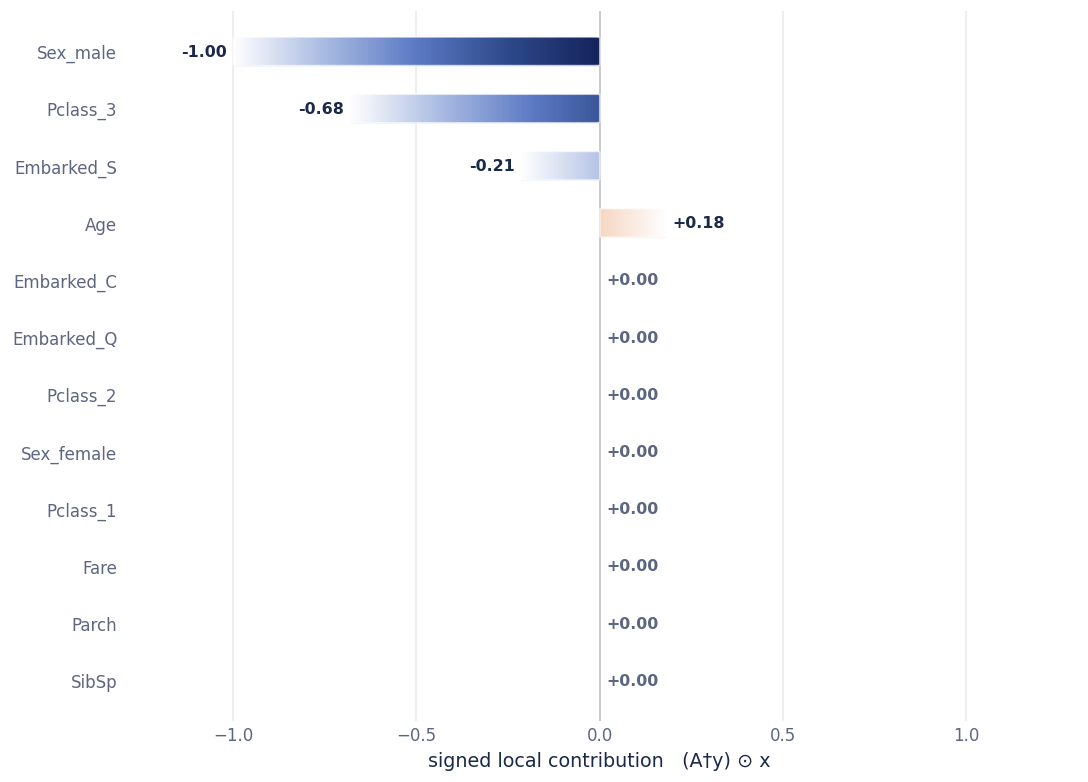

,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0.180874,0.0,-0.0,-0.0,-0.0,-0.0,-0.680227,-0.0,-1.0,-0.0,-0.0,-0.214828


In [16]:
explainer.local_feature_importance(
    movie_titanic.loc['Jack'].values, [0, 1],
    feature_names=column_features, scaler=explainer.scaler,
    ignore_zero_features=True)

### Hadamard decomposition of a local explanation  *(unique to AIME)*
Shows the local explanation being assembled as `global pull × instance`.
Features that are **absent** in this passenger collapse to exactly zero.

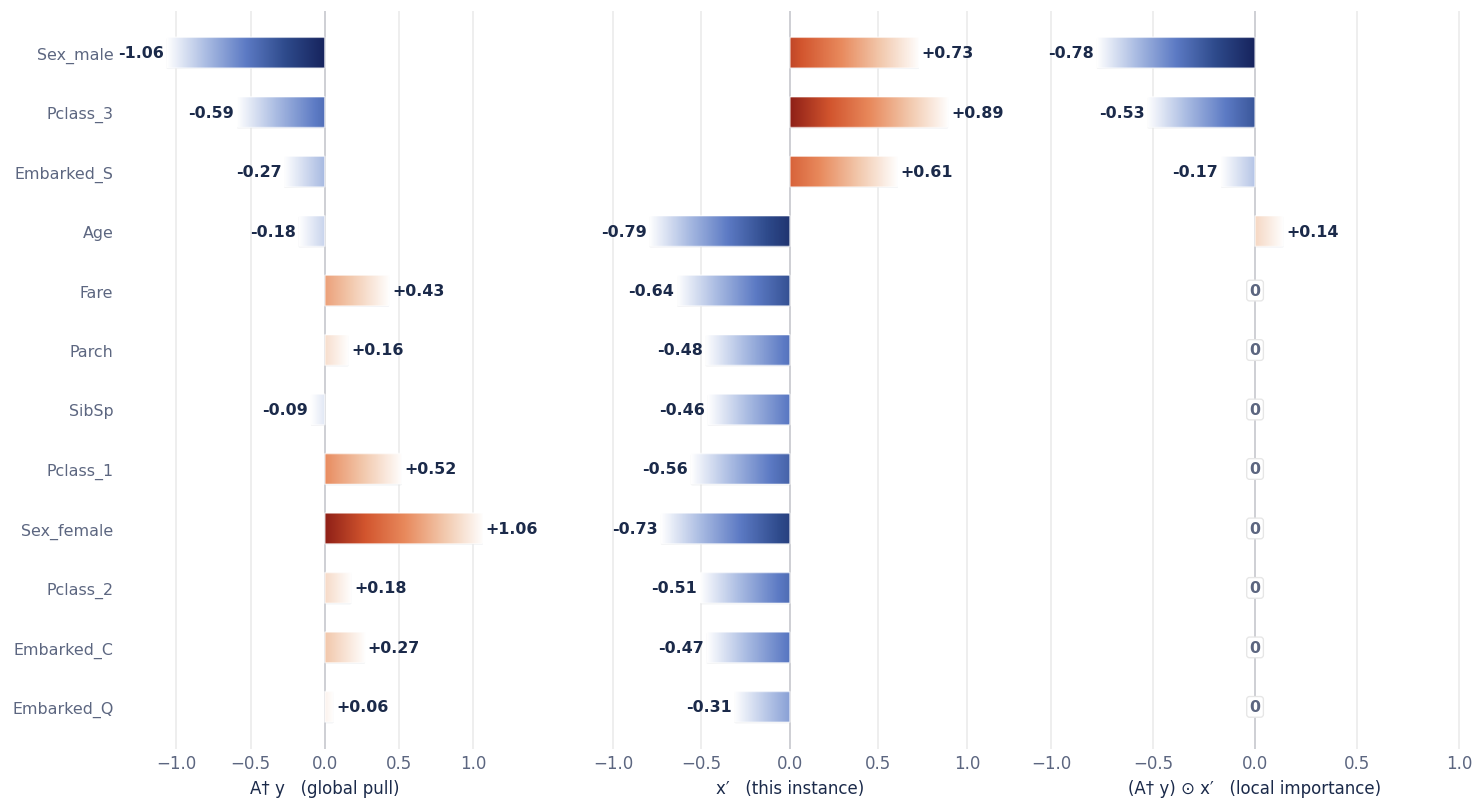

,pull,x,prod
Embarked_Q,0.060377,-0.314270,-0.000000
Embarked_C,0.270590,-0.470393,-0.000000
Pclass_2,0.178953,-0.507888,-0.000000
Sex_female,1.064500,-0.728823,-0.000000
Pclass_1,0.519010,-0.560047,-0.000000
SibSp,-0.093615,-0.464452,0.000000
Parch,0.160433,-0.477410,-0.000000
Fare,0.432852,-0.635986,-0.000000
Age,-0.176749,-0.793937,0.140328
Embarked_S,-0.273315,0.609811,-0.166670


In [17]:
explainer.plot_local_hadamard_decomposition(
    movie_titanic.loc['Jack'].values, np.array([0.0, 1.0]),
    feature_names=column_features, top_k=12)

### Representative estimation instances  *(unique to AIME)*
`A† eₜ` — the *ideal passenger* the model associates with each outcome, shown as
a feature fingerprint.

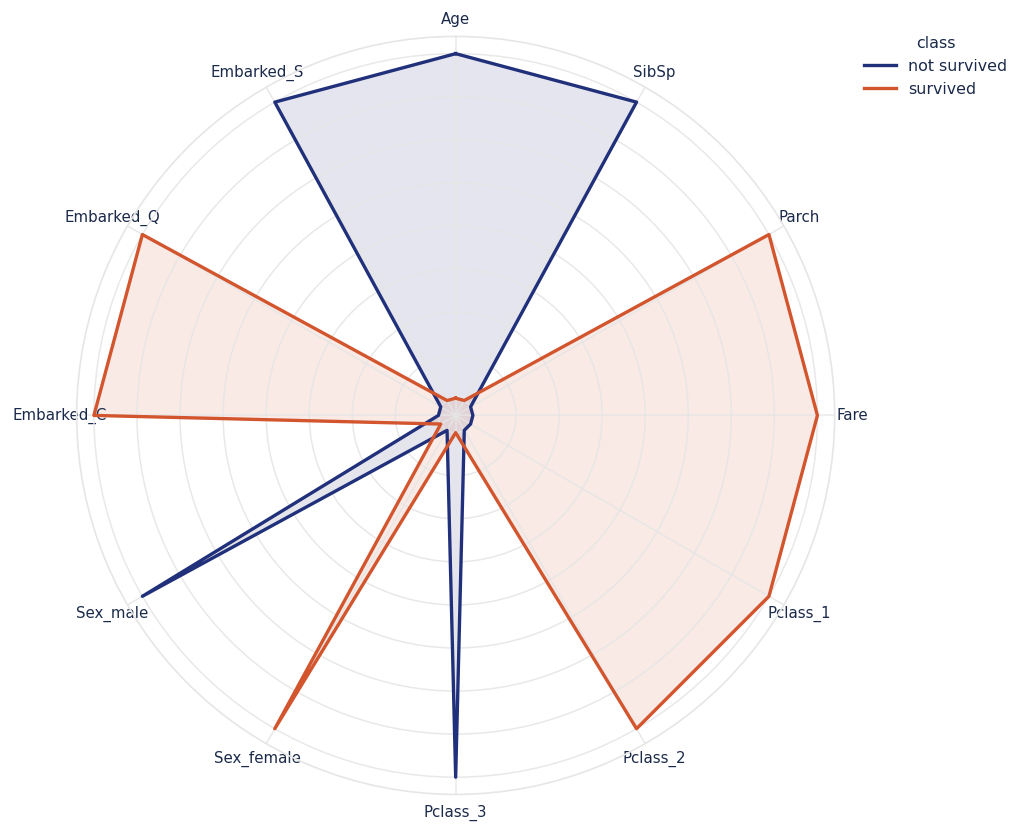

,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
not survived,30.839822,0.595886,0.309936,18.372475,0.101116,0.160110,0.738774,0.031707,0.968293,0.116345,0.079145,0.804510
survived,27.084390,0.422770,0.523536,53.548870,0.460032,0.277307,0.262661,0.853598,0.146402,0.285402,0.107157,0.607441


In [18]:
rep = explainer.representative_instance(
    scaler=explainer.scaler, feature_names=column_features, class_names=class_names)
explainer.plot_representative_instance(
    scaler=explainer.scaler, feature_names=column_features, class_names=class_names)
rep

### Representative instance similarity field
Where the two class fields overlap is the model's *hard* region. The gold star is Rose.

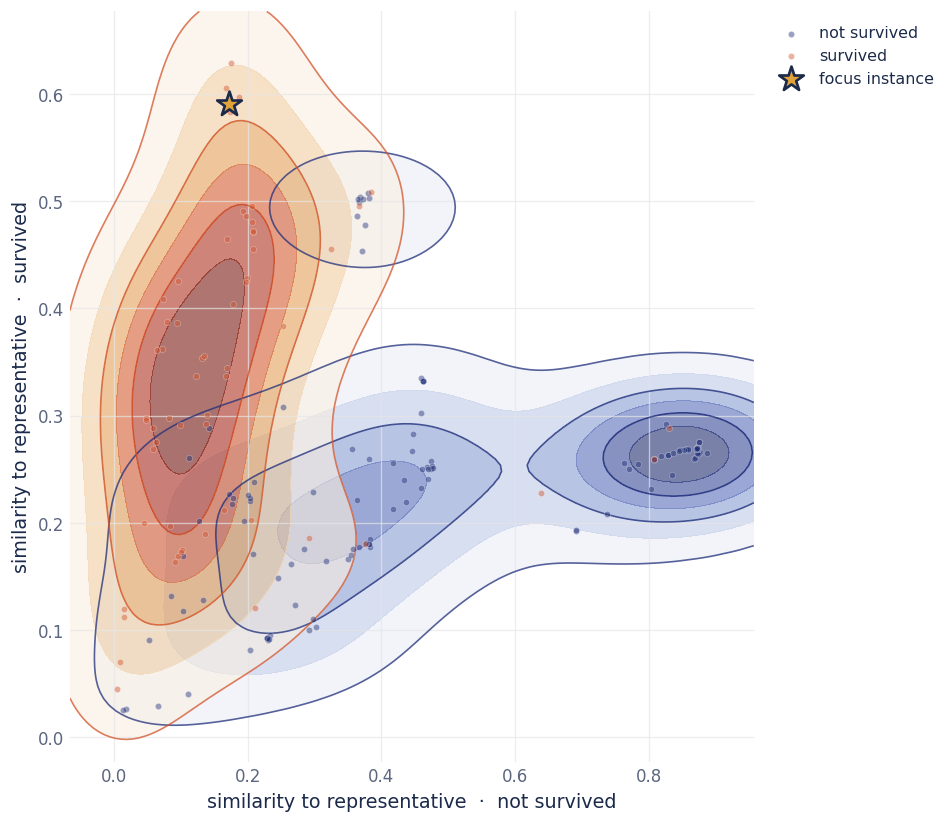

,not survived score,survived score,result
0,0.383530,0.184916,0
1,0.872012,0.268953,0
2,0.065793,0.029590,0
3,0.047057,0.298009,1
4,0.111706,0.260360,0


In [19]:
repdf, resdf = explainer.plot_rep_instance_similarity(
    X_test, y_hat_test, x=movie_titanic.loc['Rose'].values,
    feature_names=column_features, class_names=class_names,
    gamma=0.1, scaler=explainer.scaler, class_indices=[0, 1])
resdf.head()

### Interactive explorers  *(render inline in Colab)*
Both methods return an object that displays inline when it is the last
expression in a Colab/Jupyter cell. Pass `path=...` to also save a standalone
`.html` you can open in any browser.

**(a) Inverse operator flow** — hover/click a class to trace its ribbons back to
the features.

In [20]:
explainer.interactive_operator_flow(
    feature_names=column_features, class_names=class_names)

**(b) Inverse Reconstruction Explorer** *(uniquely AIME)* — drag the class
sliders to set a target output `y`; the page reconstructs, live, the input
`x = scaler⁻¹(A†·y)` the model would need. The class buttons jump to each pure
representative instance.

In [21]:
explainer.interactive_reconstruction(
    feature_names=column_features, class_names=class_names,
    path='aime_titanic_reconstruction.html')

---
# The AIME family — five variants, one API

Every variant is the **same** `AIME` class with different flags, and every
variant works with **all** of the signature visualisations above. The operator
mathematics is unchanged from the canonical papers:

| Variant | Flags | Idea |
|---|---|---|
| **AIME** | *(defaults)* | Moore–Penrose pseudo-inverse |
| **HuberAIME** | `use_huber=True` | outlier-robust IRLS |
| **RidgeAIME** | `use_ridge=True` | ℓ2-regularised closed form |
| **Huber-RidgeAIME** | `use_huber=True, use_ridge=True` | robust **and** regularised |
| **BayesianAIME** | `use_bayesian=True` | posterior mean **+ 95% credible intervals** |


In [22]:
variants = {
    'AIME':            dict(),
    'HuberAIME':       dict(use_huber=True, delta=1.0, max_iter=50),
    'RidgeAIME':       dict(use_ridge=True, ridge_alpha=1e-3),
    'Huber-RidgeAIME': dict(use_huber=True, use_ridge=True, ridge_alpha=1e-3),
    'BayesianAIME':    dict(use_bayesian=True, bayesian_sigma=1.0, bayesian_tau=1.0),
}

explainers = {}
for name, kw in variants.items():
    e = AIME(**kw).create_explainer(X_train, y_hat_train, normalize=True)
    explainers[name] = e
    print(f'{name:18s}  variant={e.variant_name:16s}  A† shape={e.A_dagger.shape}')

AIME                variant=AIME              A† shape=(12, 2)
HuberAIME           variant=HuberAIME         A† shape=(12, 2)
RidgeAIME           variant=RidgeAIME         A† shape=(12, 2)
Huber-RidgeAIME     variant=Huber-RidgeAIME   A† shape=(12, 2)
BayesianAIME        variant=BayesianAIME      A† shape=(12, 2)


### Global feature importance — every variant, same signature view
Each renders the operator field + per-class signed bars. Compare how Ridge/Huber reshape the weights.

— AIME


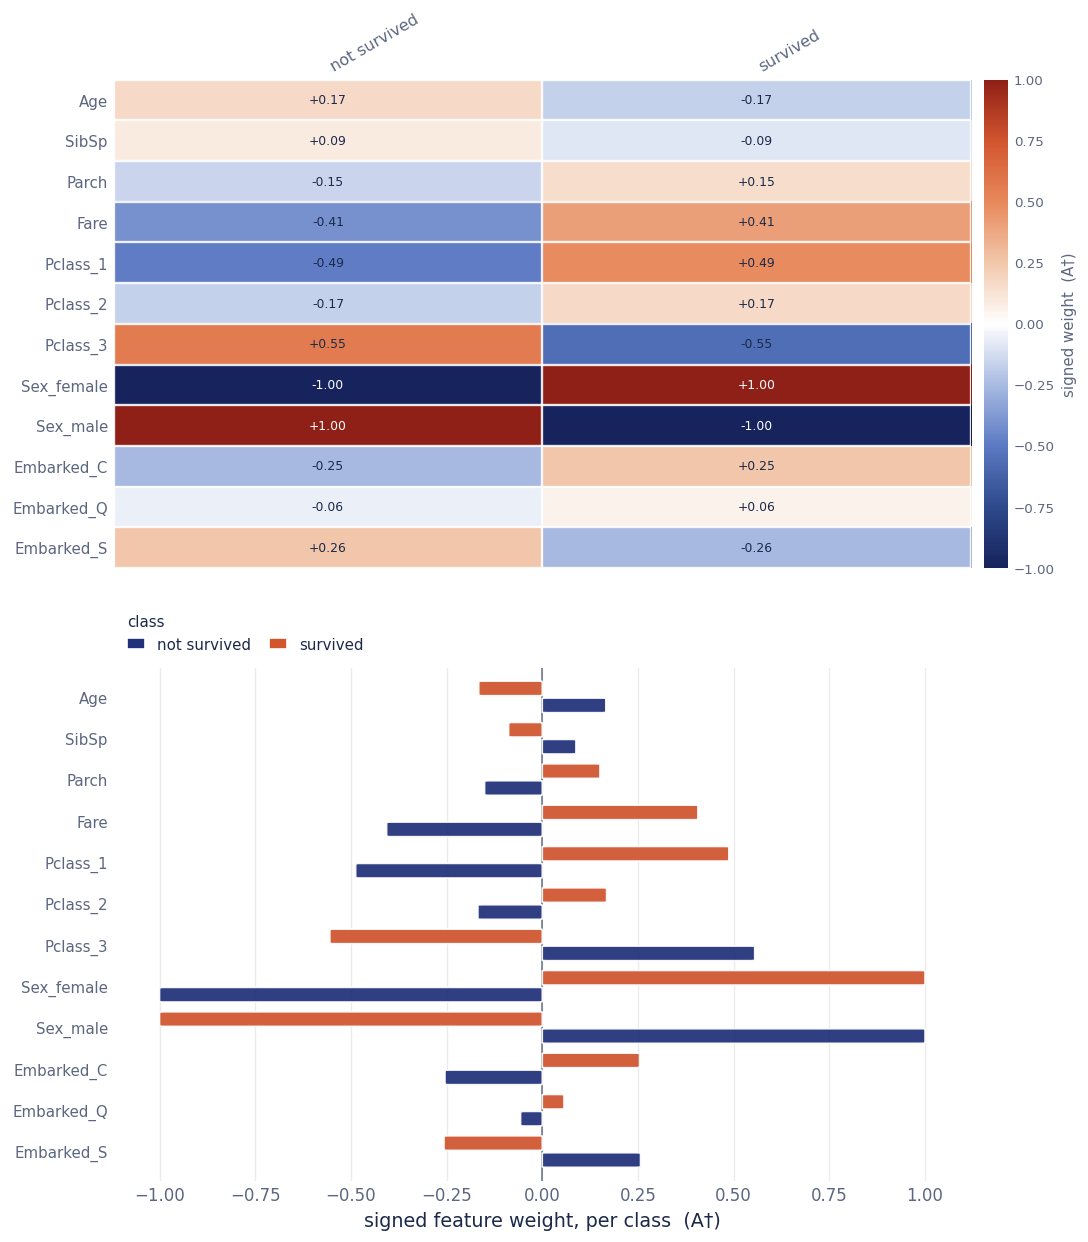

— HuberAIME


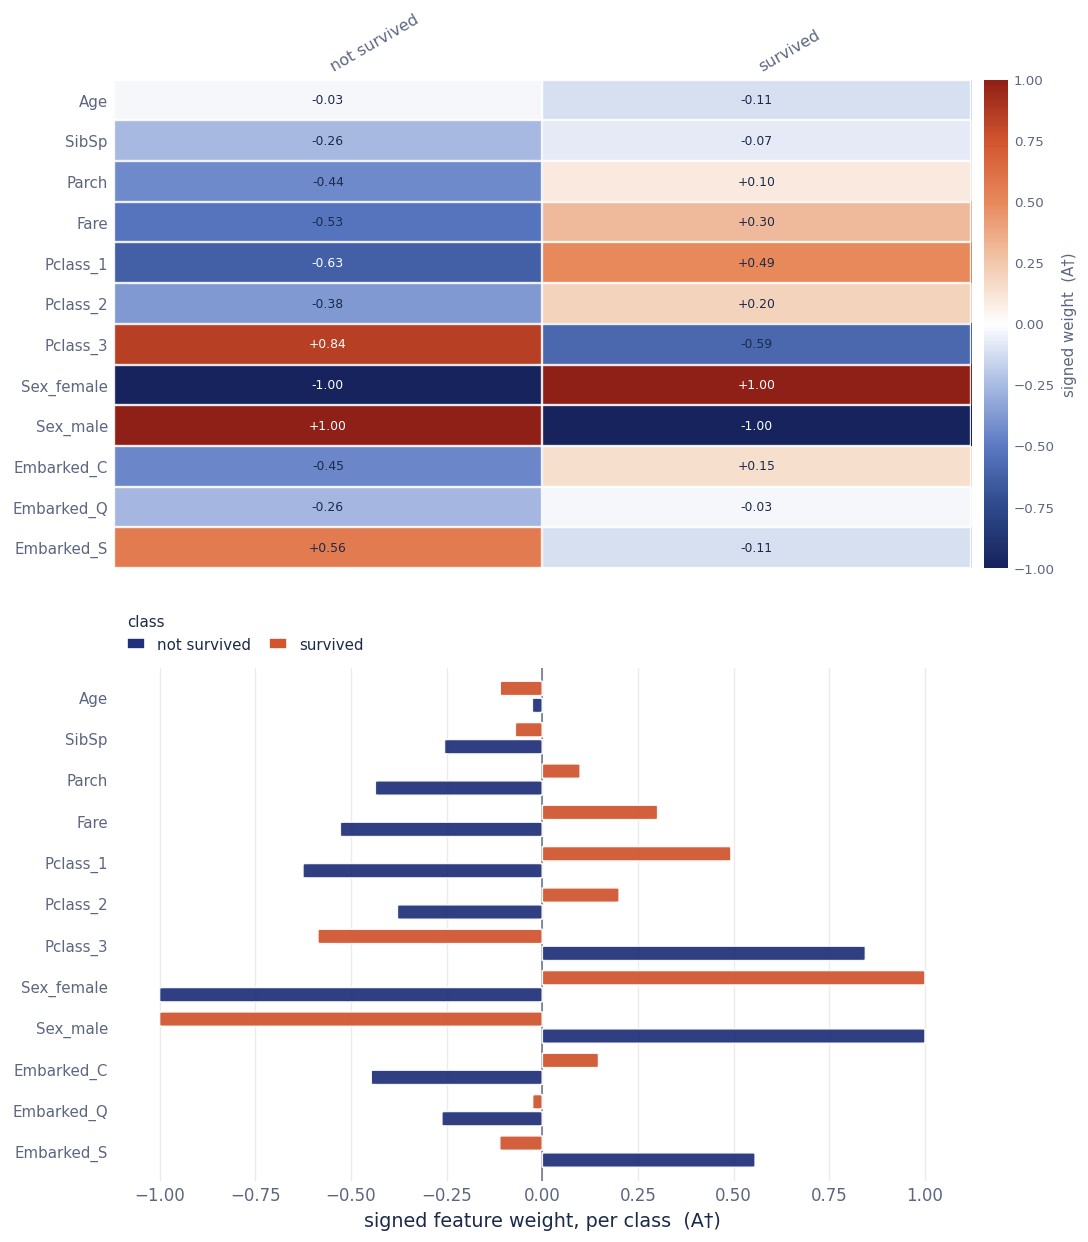

— RidgeAIME


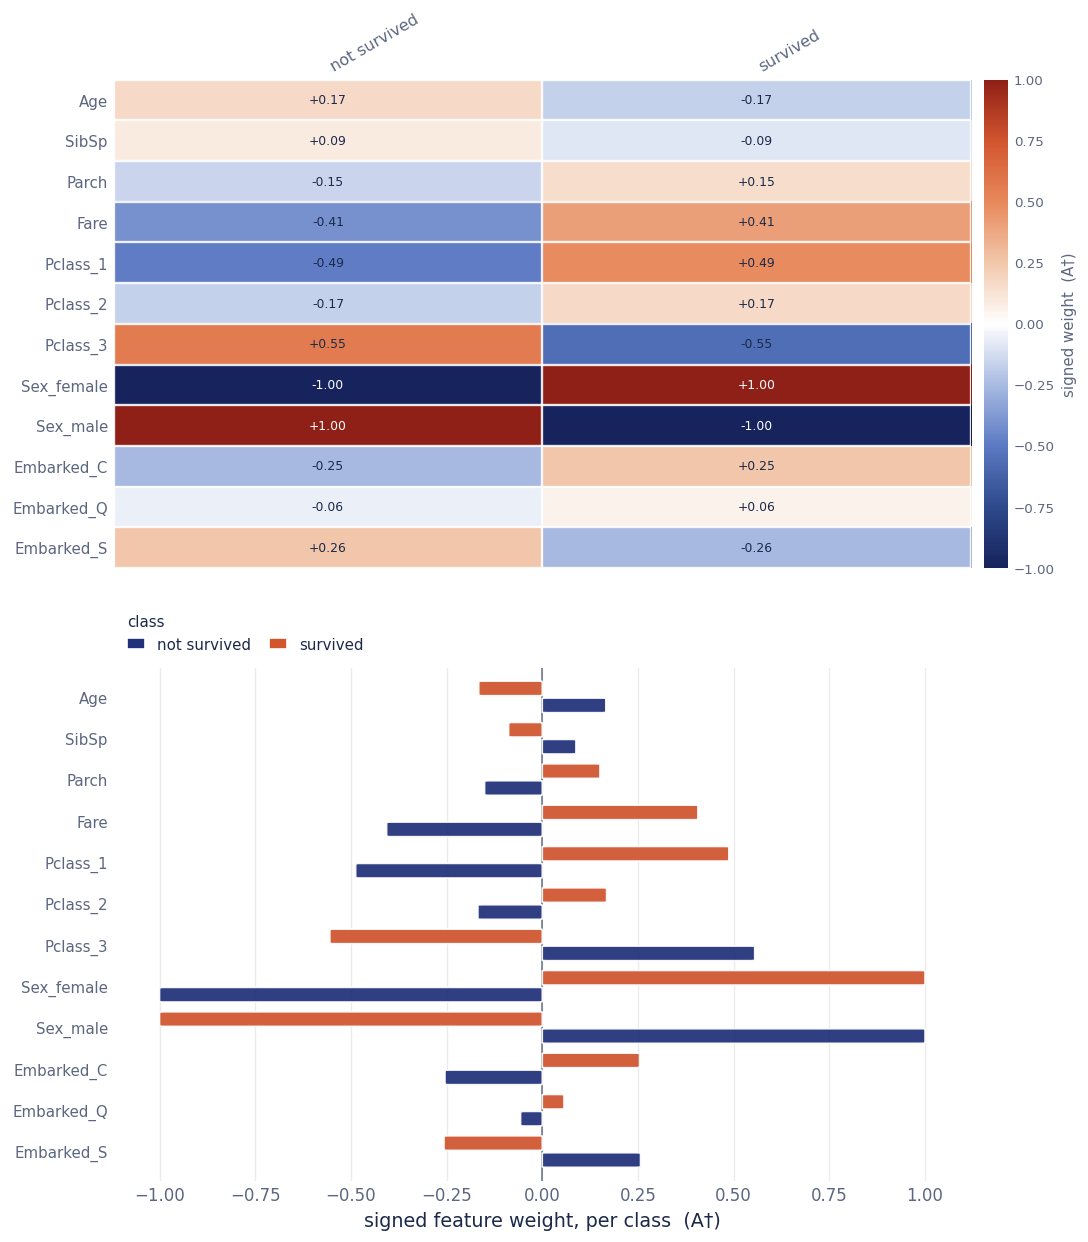

— Huber-RidgeAIME


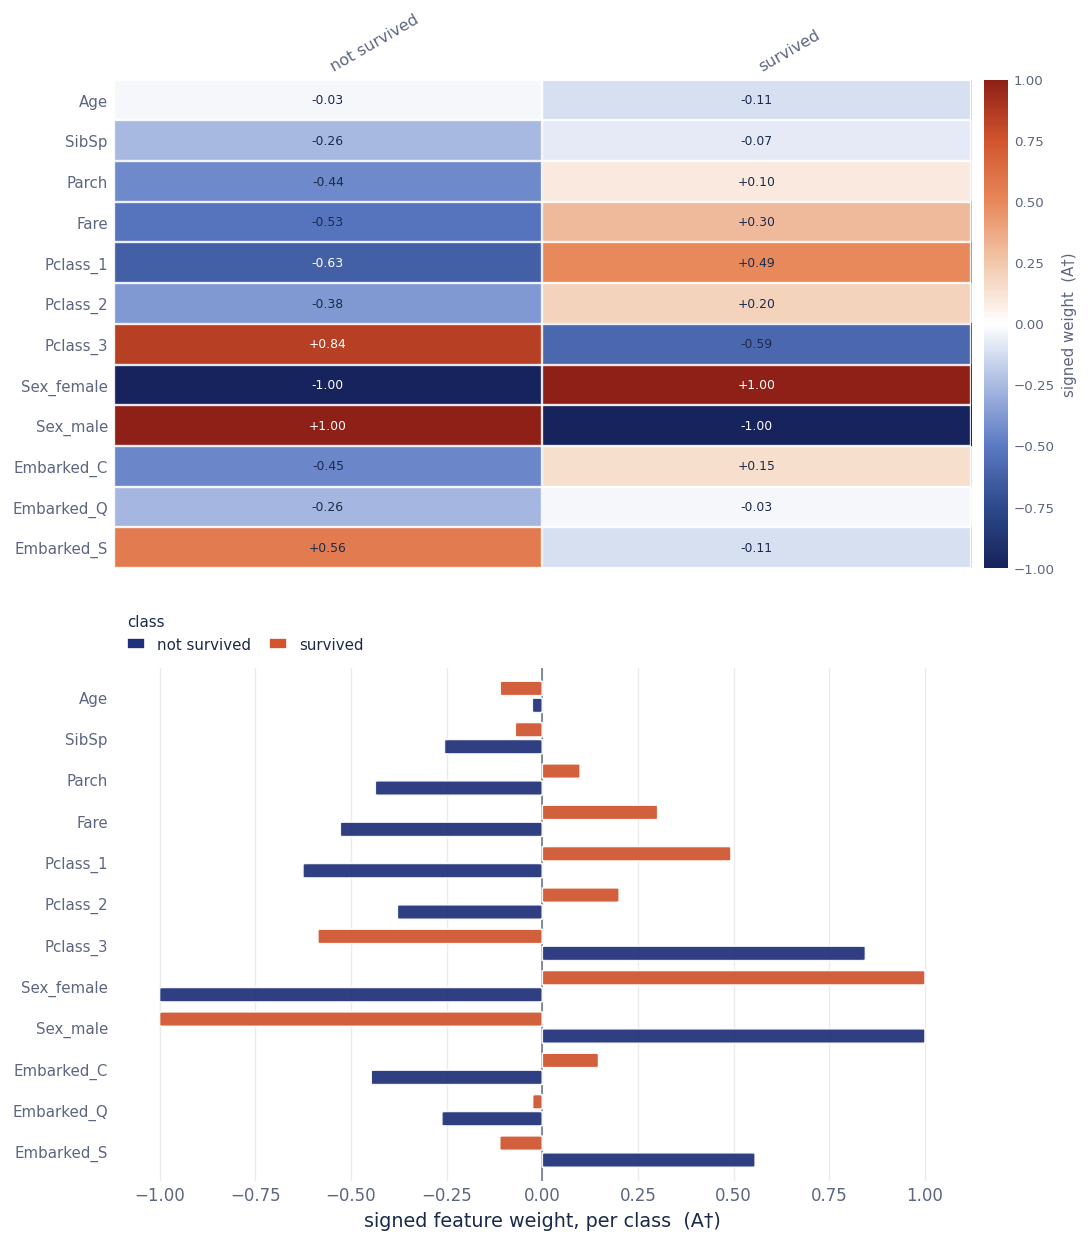

— BayesianAIME


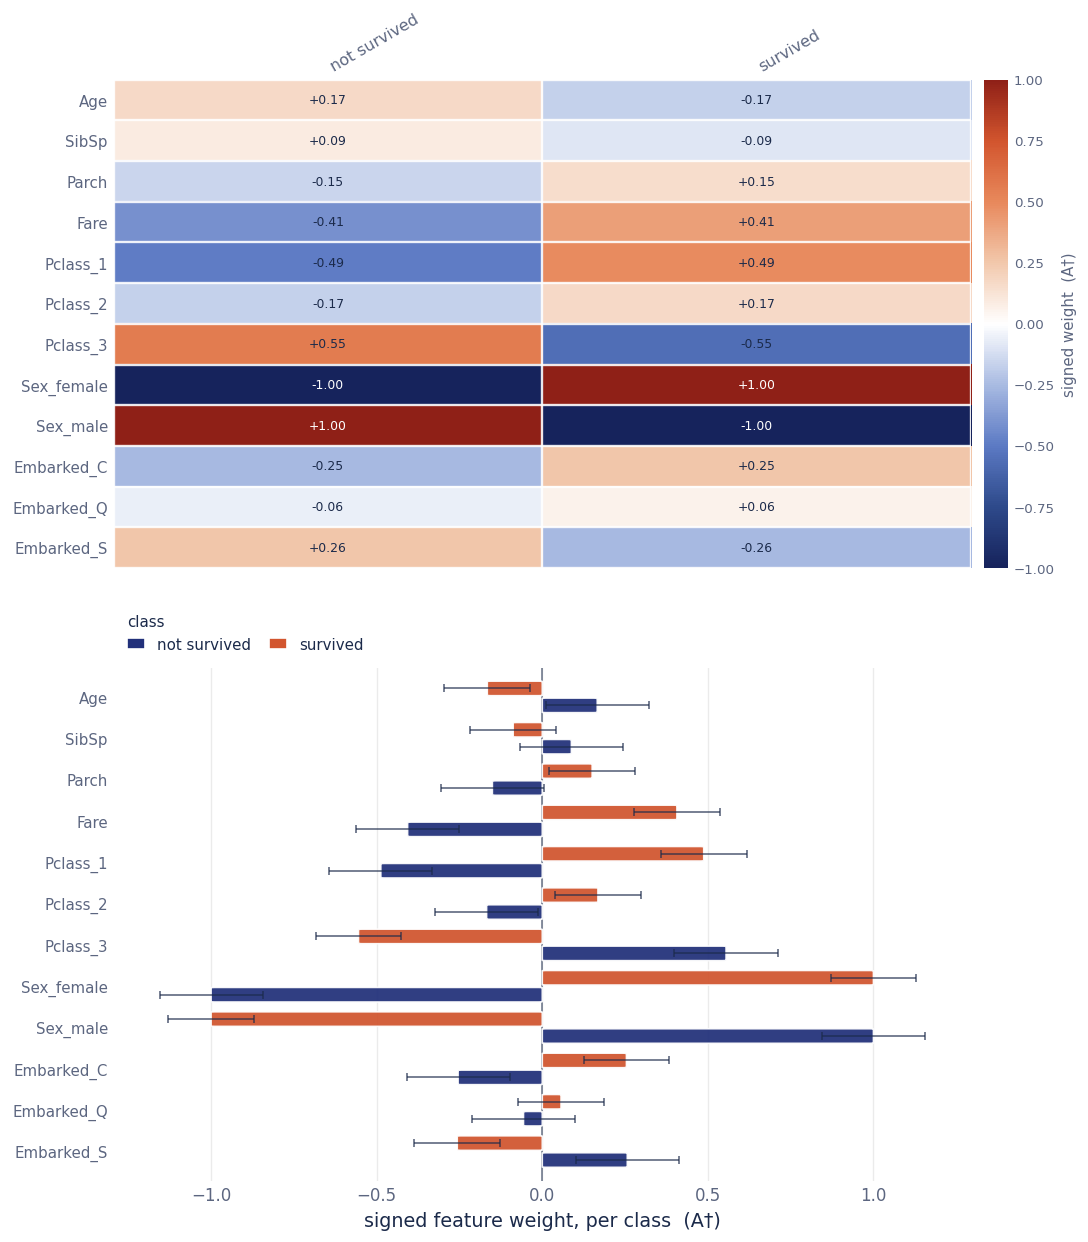

In [23]:
for name, e in explainers.items():
    print('—', name)
    e.global_feature_importance(feature_names=column_features, class_names=class_names)

### BayesianAIME — global importance **with 95% credible intervals**
Only the inverse-operator formulation gives a posterior over the explanation.
The per-class bars now carry credible-interval whiskers, and the returned frame
holds `mean / lower_bound / upper_bound`.

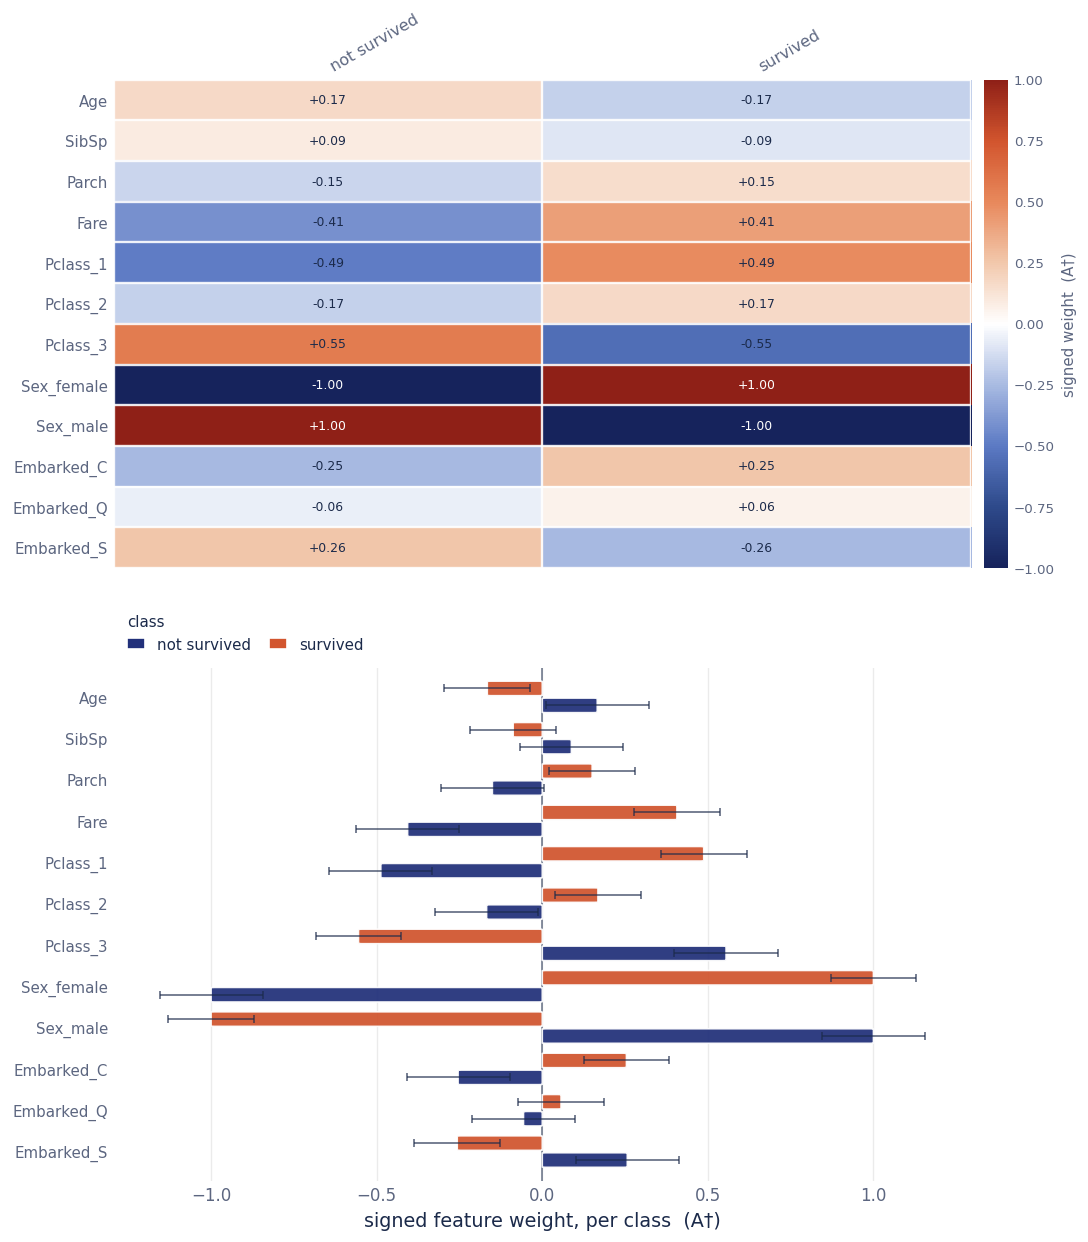

Age                        Embarked_C            \
             lower_bound      mean upper_bound lower_bound      mean   
not survived    0.010312  0.166039    0.321766   -0.409921 -0.254194   
survived       -0.295255 -0.166039   -0.036824    0.124979  0.254194   

                          Embarked_Q                        Embarked_S  ...  \
             upper_bound lower_bound      mean upper_bound lower_bound  ...   
not survived   -0.098467   -0.212446 -0.056719    0.099008    0.101027  ...   
survived        0.383409   -0.072496  0.056719    0.185934   -0.385969  ...   

                Pclass_3  Sex_female                     Sex_male       \
             upper_bound lower_bound mean upper_bound lower_bound mean   
not survived    0.710710   -1.155727 -1.0   -0.844273    0.844273  1.0   
survived       -0.425768    0.870785  1.0    1.129215   -1.129215 -1.0   

                               SibSp                        
             upper_bound lower_bound      mean upper_bound  
not survived    1.155727   -0.067784  0.087942    0.243669  
survived       -0.870785   -0.217158 -0.087942    0.041273  

[2 rows x 36 columns]

In [24]:
bayes = explainers['BayesianAIME']
bayes_global = bayes.global_feature_importance(
    feature_names=column_features, class_names=class_names)
bayes_global

### BayesianAIME — local explanation with credible intervals (Jack)

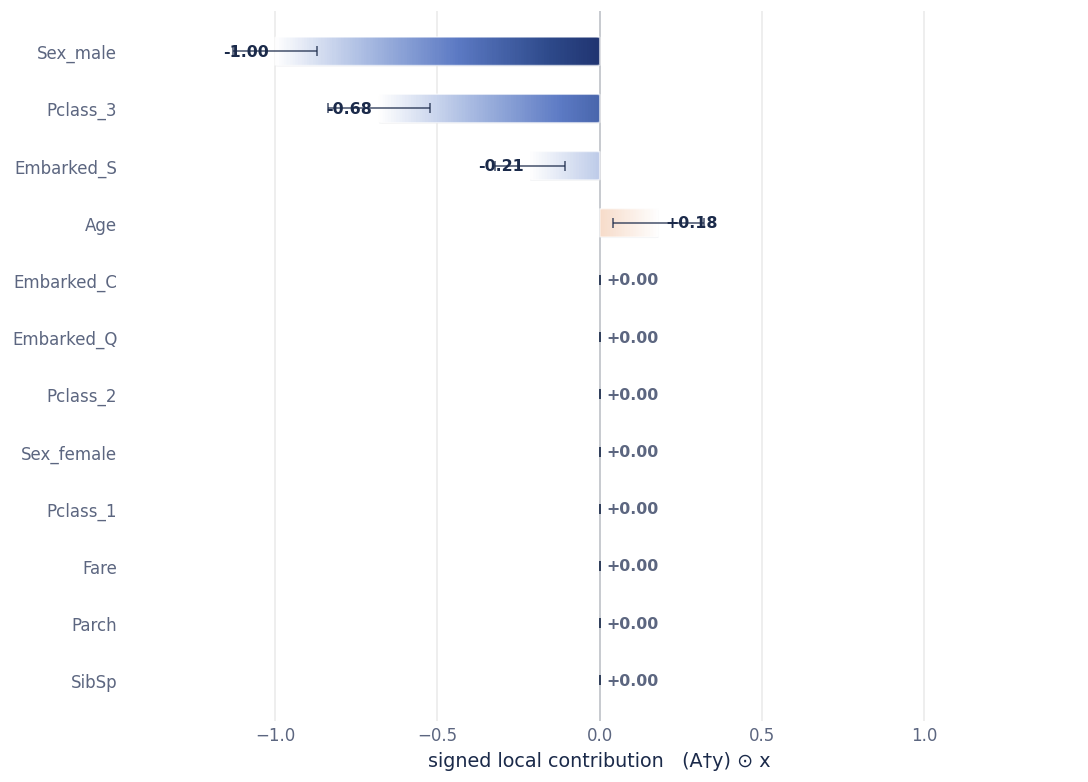

,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
mean,0.180874,0.0,-0.0,-0.0,-0.0,-0.0,-0.680227,-0.0,-1.000000,-0.0,-0.0,-0.214828
lower_bound,0.040114,0.0,-0.0,-0.0,-0.0,-0.0,-0.838602,-0.0,-1.129215,-0.0,-0.0,-0.322943
upper_bound,0.321633,0.0,0.0,0.0,0.0,0.0,-0.521851,0.0,-0.870785,0.0,0.0,-0.106713


In [25]:
bayes_local = bayes.local_feature_importance(
    movie_titanic.loc['Jack'].values, [0, 1],
    feature_names=column_features, ignore_zero_features=True)
bayes_local

### Inverse operator flow & Hadamard decomposition also work for every variant
Example with HuberAIME and Huber-RidgeAIME:

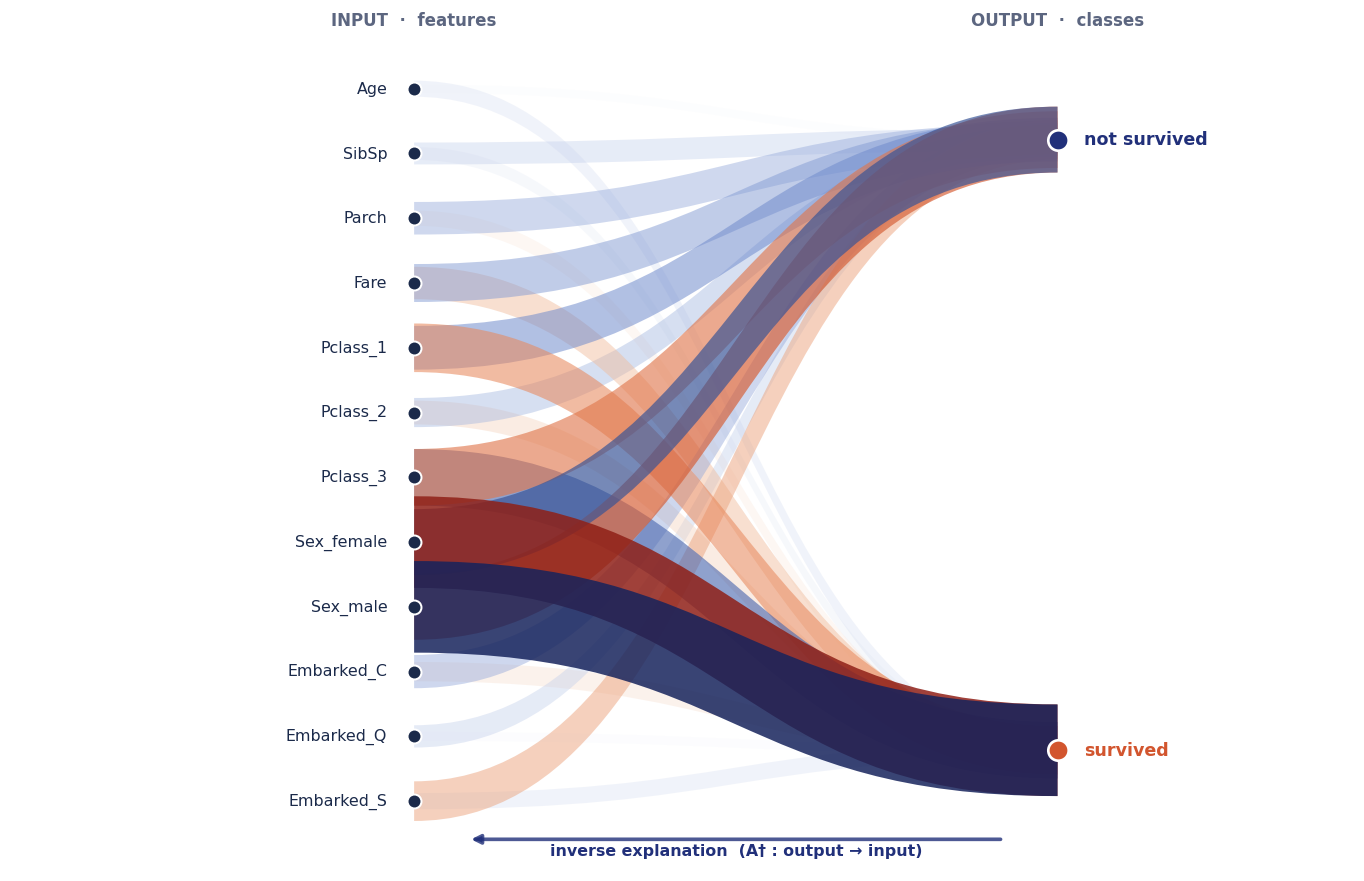

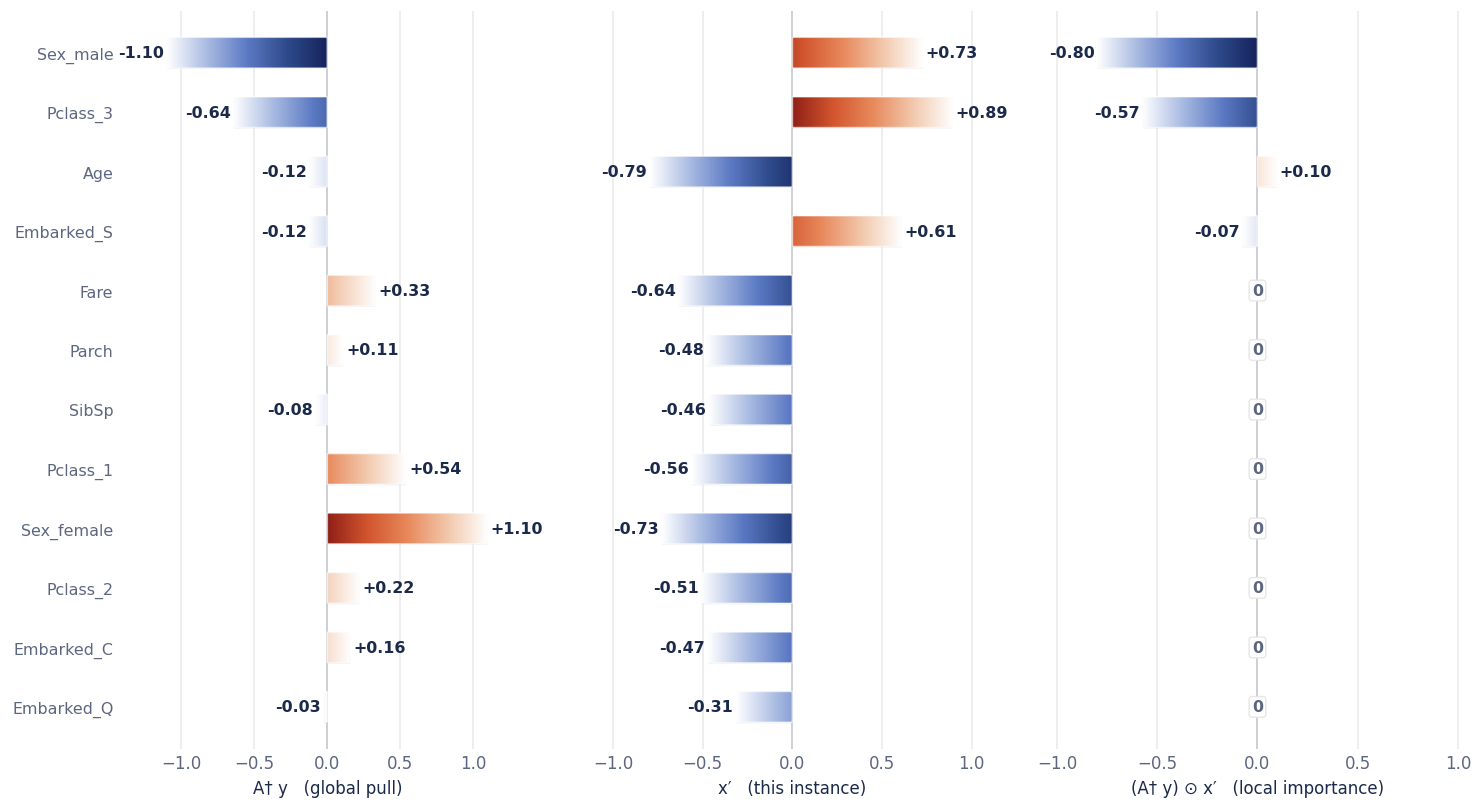

,pull,x,prod
Embarked_Q,-0.027695,-0.314270,0.000000
Embarked_C,0.161248,-0.470393,-0.000000
Pclass_2,0.220212,-0.507888,-0.000000
Sex_female,1.096016,-0.728823,-0.000000
Pclass_1,0.540348,-0.560047,-0.000000
SibSp,-0.077334,-0.464452,0.000000
Parch,0.108637,-0.477410,-0.000000
Fare,0.330558,-0.635986,-0.000000
Embarked_S,-0.121901,0.609811,-0.074336
Age,-0.120531,-0.793937,0.095694


In [26]:
explainers['HuberAIME'].plot_inverse_operator_flow(
    feature_names=column_features, class_names=class_names)
explainers['Huber-RidgeAIME'].plot_local_hadamard_decomposition(
    movie_titanic.loc['Jack'].values, np.array([0.0, 1.0]),
    feature_names=column_features, top_k=12)

### Does each variant actually change the explanation on Titanic?

**HuberAIME does** (it down-weights outliers and reshapes the importances), so a
normalised AIME-vs-Huber comparison is informative:

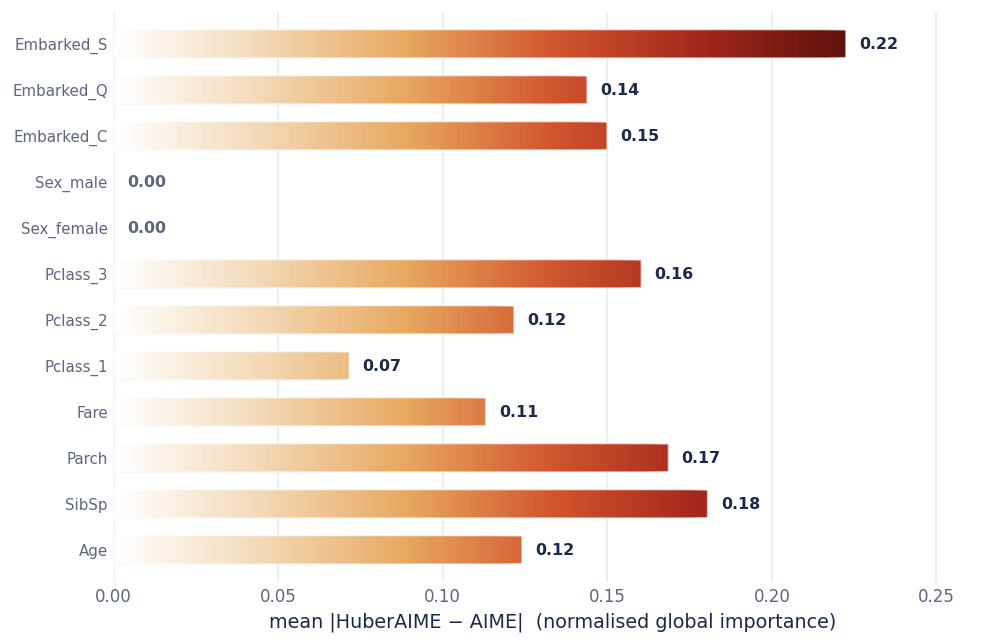

In [27]:
import aime_xai.style as S
S.apply_aime_style()
g0 = explainers['AIME'].global_feature_importance_without_viz(
    feature_names=column_features, class_names=class_names)
gh = explainers['HuberAIME'].global_feature_importance_without_viz(
    feature_names=column_features, class_names=class_names)
diff = (gh - g0).abs().mean(axis=0).reindex(g0.columns)
vmax = float(diff.max()) or 1.0
fig, ax = S.new_figure(figsize=(8.5, 5.5))
for i, feat in enumerate(g0.columns):
    S.gradient_hbar(ax, i, float(diff[feat]), vmax=vmax, height=0.62, mode='sequential')
ax.set_yticks(range(len(g0.columns))); ax.set_yticklabels(list(g0.columns), fontsize=9)
ax.set_xlim(0, vmax*1.2); ax.set_ylim(-0.7, len(g0.columns)-0.3)
ax.set_xlabel('mean |HuberAIME − AIME|  (normalised global importance)')
fig.tight_layout(); plt.show()

**RidgeAIME barely does, for two reasons** — verified below by sweeping `λ`:

1. **λ is tiny relative to the problem.** Ridge's `λI` competes with `YᵀY`,
   whose eigenvalues scale with the sample size (≈ N). For Titanic (N≈700) those
   eigenvalues are ~10²–10³, so the default `λ=1e-3` changes the *raw* operator
   `A†` by only ~1e-5. Ridge only becomes active once `λ` reaches that band.
2. **Binary + normalisation cancels it.** With two classes, Ridge rescales each
   class column of `A†` by an almost-constant factor, and the per-class peak
   normalisation in the global-importance view divides that out. So even a large
   `λ` (which *does* change the raw operator) leaves the **normalised** importance
   essentially unchanged. (For ≥3 classes this cancellation is only partial.)

The diagnostic: raw-operator change rises with `λ`, while normalised global
importance stays at machine-zero.

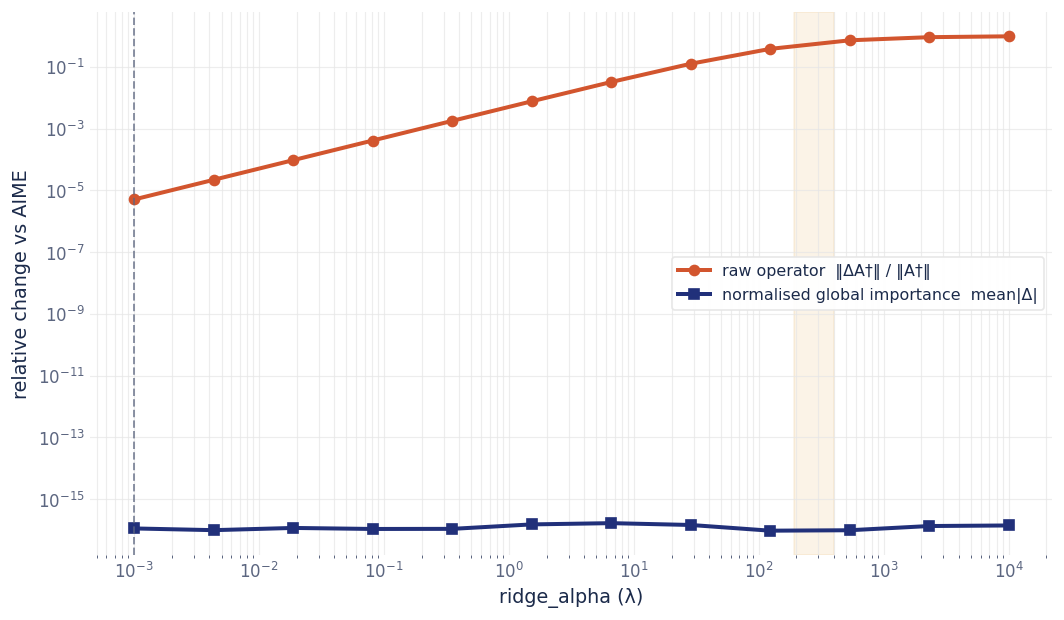

eig(YᵀY) = [191.8 397.9] — λ must be comparable to these to act


In [28]:
import numpy as np, numpy.linalg as la
A0 = explainers['AIME'].A_dagger
alphas = np.logspace(-3, 4, 12)
raw, norm = [], []
for a in alphas:
    e = AIME(use_ridge=True, ridge_alpha=a).create_explainer(X_train, y_hat_train, normalize=True)
    raw.append(la.norm(e.A_dagger - A0) / la.norm(A0))
    norm.append(float((e.global_feature_importance_without_viz(
        feature_names=column_features, class_names=class_names) - g0).abs().mean().mean()))

fig, ax = S.new_figure(figsize=(9, 5.3))
ax.plot(alphas, raw, '-o', color=S.CORAL, lw=2.4, ms=6,
        label='raw operator  ‖ΔA†‖ / ‖A†‖')
ax.plot(alphas, np.clip(norm, 1e-17, None), '-s', color=S.INDIGO, lw=2.4, ms=6,
        label='normalised global importance  mean|Δ|')
ev = la.eigvalsh(y_hat_train.T @ y_hat_train)
ax.axvspan(ev.min(), ev.max(), color=S.AMBER, alpha=0.12)
ax.axvline(1e-3, color=S.INK_SOFT, ls='--', lw=1.2, alpha=0.7)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('ridge_alpha (λ)'); ax.set_ylabel('relative change vs AIME')
ax.grid(True, which='both', color=S.GRIDLINE, lw=0.7, alpha=0.7)
ax.legend(loc='center right', frameon=True, framealpha=0.95, edgecolor=S.GRIDLINE, fontsize=9.5)
fig.tight_layout(); plt.show()
print('eig(YᵀY) =', np.round(ev, 1), '— λ must be comparable to these to act')

## Takeaways
- A single `AIME` class provides **five variants** (AIME, HuberAIME, RidgeAIME,
  Huber-RidgeAIME, BayesianAIME) — all sharing the same signature visualisations.
- AIME derives **global** and **local** explanations from one inverse operator
  `A†` — no perturbation or sampling. The **Hadamard** local rule keeps absent
  features at exactly zero.
- **HuberAIME** resists outliers; **RidgeAIME** regularises; **BayesianAIME**
  adds **95% credible intervals** on every importance — uncertainty that
  forward-problem methods (LIME/SHAP) do not provide.
- The **inverse operator flow**, **representative instances**, **Hadamard
  decomposition**, **similarity field** and the **interactive explorers** are all
  unique to the inverse-operator view.